In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#path to csv 
file_path = '../data/raw/fraud_detection_cdr.csv' 

# Loading data
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\n--- Column Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

Dataset Shape: (101174, 17)

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 101174 entries, 0 to 101173
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Phone Number    101174 non-null  str    
 1   Account Length  101174 non-null  int64  
 2   VMail Message   101174 non-null  int64  
 3   Day Mins        101174 non-null  float64
 4   Day Calls       101174 non-null  int64  
 5   Day Charge      101174 non-null  float64
 6   Eve Mins        101174 non-null  float64
 7   Eve Calls       101174 non-null  int64  
 8   Eve Charge      101174 non-null  float64
 9   Night Mins      101174 non-null  float64
 10  Night Calls     101174 non-null  int64  
 11  Night Charge    101174 non-null  float64
 12  Intl Mins       101174 non-null  float64
 13  Intl Calls      101174 non-null  int64  
 14  Intl Charge     101174 non-null  float64
 15  CustServ Calls  101174 non-null  int64  
 16  isFraud         10

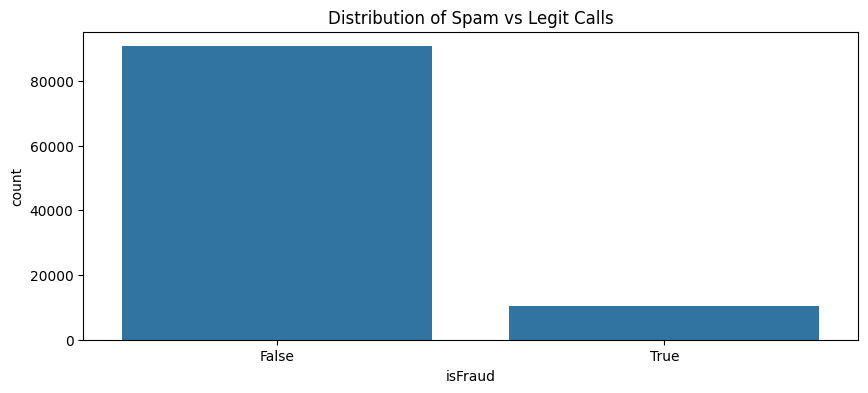

Percentage of Spam: 10.409789076244886 %


In [42]:

label_col = 'isFraud' 

plt.figure(figsize=(10,4))
sns.countplot(x=label_col, data=df)
plt.title('Distribution of Spam vs Legit Calls')
plt.show()


print("Percentage of Spam:", (df[label_col].sum() / len(df)) * 100, "%")

In [44]:
print(df.columns)


Index(['Phone Number', 'Account Length', 'VMail Message', 'Day Mins',
       'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge',
       'Night Mins', 'Night Calls', 'Night Charge', 'Intl Mins', 'Intl Calls',
       'Intl Charge', 'CustServ Calls', 'isFraud'],
      dtype='str')


In [45]:
df["total_mins"] = df["Day Mins"] + df["Eve Mins"] + df["Night Mins"] + df["Intl Mins"]
df["total_calls"] = df["Day Calls"] + df["Eve Calls"] + df["Night Calls"] + df["Intl Calls"]
df["avg_call_duration"] = df["total_mins"] / df["total_calls"]
df["high_complaint"] = df["CustServ Calls"] > 3
df.groupby("high_complaint")["isFraud"].mean()
df[["total_mins", "total_calls", "avg_call_duration"]].head(10)

,total_mins,total_calls,avg_call_duration
0,717.2,303,2.366997
1,625.2,332,1.883133
2,539.4,333,1.619820
3,564.8,255,2.214902
4,512.0,359,1.426184
5,654.2,323,2.025387
6,786.8,321,2.451090
7,479.0,275,1.741818
8,760.6,271,2.806642
9,818.2,297,2.754882


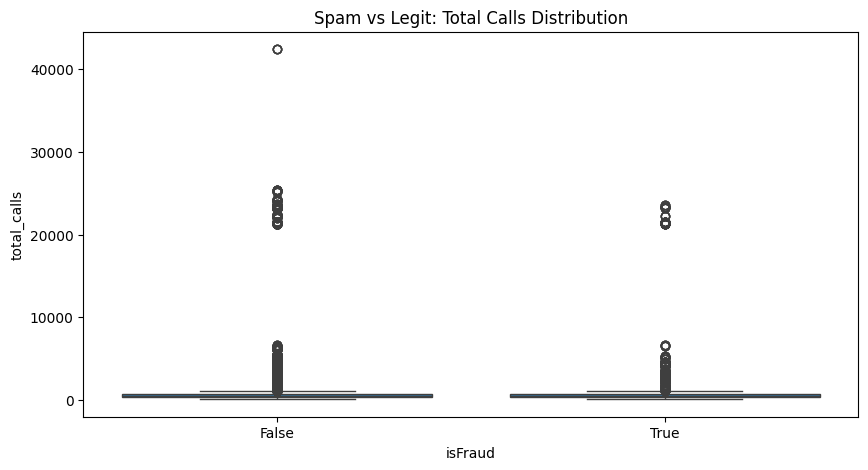

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'total_calls' behaves differently for Spam (1) vs Legit (0)
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='total_calls', data=df)
plt.title('Spam vs Legit: Total Calls Distribution')
plt.show()

In [47]:
from sqlalchemy import create_engine

# Ye details hamare docker-compose file se aayi hain [cite: 35, 38]
DB_USER = "admin"
DB_PASS = "password123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "telecom_db"

# Engine (Pipe) taiyar karna
conn_string = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(conn_string)
print("Connection Engine Ready!")

Connection Engine Ready!


In [48]:
df.to_sql(
    'caller_features',
    engine,
    if_exists='replace',
    index=False
)

print("🔥 Data DB me save ho gaya")

🔥 Data DB me save ho gaya


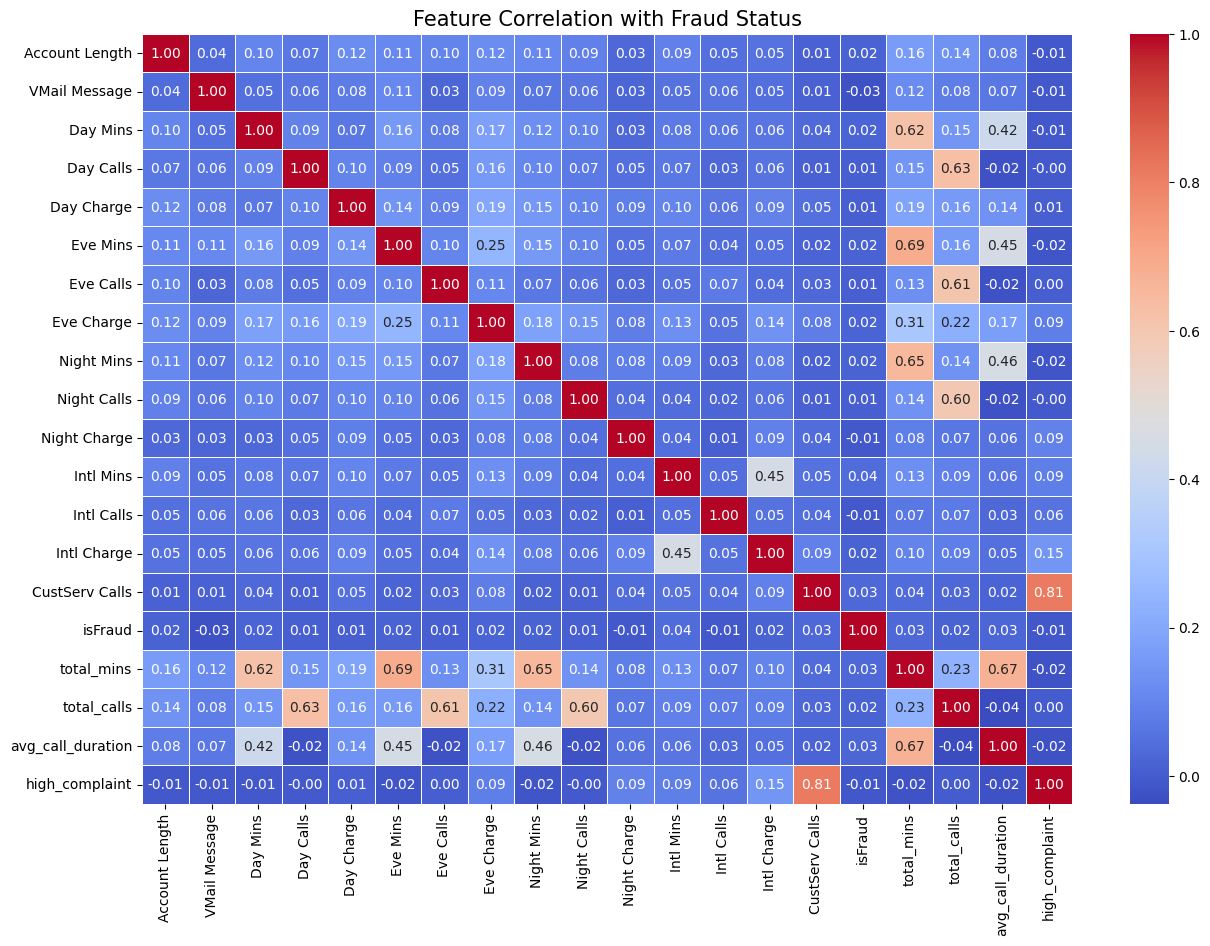

Top Correlations with Fraud:
isFraud              1.000000
Intl Mins            0.035720
total_mins           0.030435
CustServ Calls       0.027743
avg_call_duration    0.026524
Day Mins             0.022407
Eve Charge           0.019786
Night Mins           0.019012
Eve Mins             0.018400
Account Length       0.015346
total_calls          0.015244
Intl Charge          0.015211
Night Calls          0.009511
Eve Calls            0.009291
Day Calls            0.009258
Day Charge           0.006960
Night Charge        -0.005662
Intl Calls          -0.009195
high_complaint      -0.012358
VMail Message       -0.025019
Name: isFraud, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sirf numerical columns select karna (taaki ValueError na aaye)
numerical_df = df.select_dtypes(include=['number', 'bool'])

# 2. Correlation matrix nikalna
corr = numerical_df.corr()

# 3. Heatmap plot karna
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Feature Correlation with Fraud Status", fontsize=15)
plt.show()

# Dekho 'isFraud' waali line mein kiske numbers 0.20 se zyada hain.
print("Top Correlations with Fraud:")
print(corr['isFraud'].sort_values(ascending=False))

In [50]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['number', 'bool']).drop(columns=['isFraud'], errors='ignore')
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Split Successful!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

✅ Data Split Successful!
Training set: 80939 rows
Testing set: 20235 rows


In [51]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, random_state=42)


model.fit(X_train, y_train)

print(" Model ki (Training) poori ho gayi.")

 Model ki (Training) poori ho gayi.


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


model = RandomForestClassifier(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9716333086236718

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.99      0.98     18152
        True       0.88      0.84      0.86      2083

    accuracy                           0.97     20235
   macro avg       0.93      0.91      0.92     20235
weighted avg       0.97      0.97      0.97     20235



In [53]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

Day Mins             0.082979
Day Charge           0.077733
total_mins           0.068613
Night Charge         0.064605
Eve Charge           0.064466
Eve Mins             0.063937
avg_call_duration    0.061083
Night Mins           0.061010
total_calls          0.059629
Account Length       0.056388
dtype: float64


In [54]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      0.97      0.98     18152
        True       0.76      0.87      0.81      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.92      0.89     20235
weighted avg       0.96      0.96      0.96     20235



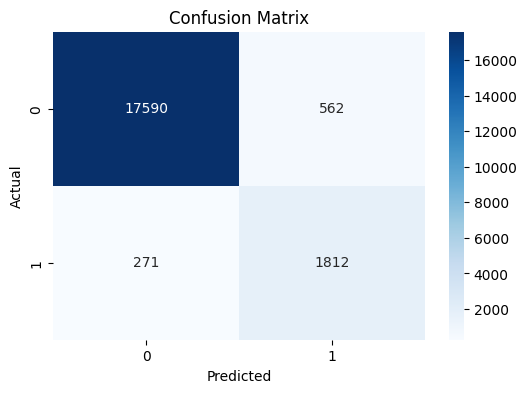

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [56]:
y_prob = model.predict_proba(X_test)[:,1]

print(y_prob[:10])

[0.02 0.   0.   0.01 0.   0.01 0.   0.01 0.   0.  ]


In [57]:
from sklearn.metrics import classification_report
y_pred_3= (y_prob>0.3).astype(int)

print("Threshold= 0.3\n")
print(classification_report(y_test, y_pred_3))



Threshold= 0.3

              precision    recall  f1-score   support

       False       0.99      0.97      0.98     18152
        True       0.75      0.89      0.82      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.93      0.90     20235
weighted avg       0.96      0.96      0.96     20235



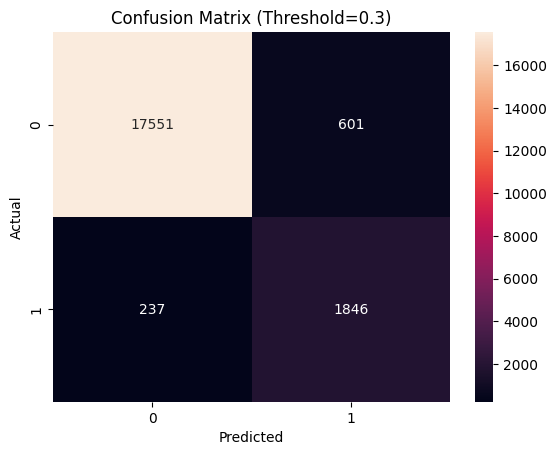

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_3)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Threshold=0.3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"\nThreshold= {t}\n")
    print(classification_report(y_test, y_pred_t))


Threshold= 0.2

              precision    recall  f1-score   support

       False       0.99      0.96      0.98     18152
        True       0.74      0.90      0.81      2083

    accuracy                           0.96     20235
   macro avg       0.86      0.93      0.89     20235
weighted avg       0.96      0.96      0.96     20235


Threshold= 0.3

              precision    recall  f1-score   support

       False       0.99      0.97      0.98     18152
        True       0.75      0.89      0.82      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.93      0.90     20235
weighted avg       0.96      0.96      0.96     20235


Threshold= 0.4

              precision    recall  f1-score   support

       False       0.99      0.97      0.98     18152
        True       0.76      0.88      0.81      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.92      0.89     20235
weighted avg       0.96

In [60]:
from sklearn.metrics import roc_auc_score
print("AUC Score:"), roc_auc_score(y_test, y_prob)


AUC Score:


(None, 0.97204934455445)

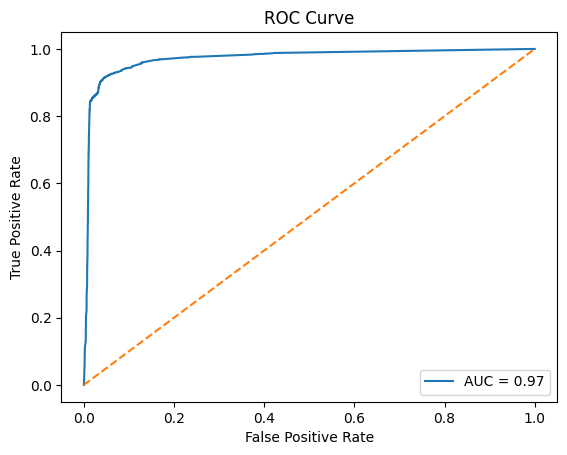

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC calculate
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
# Model Comparison 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

models= {
    "Logistic": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoost": GradientBoostingClassifier()
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob= model.predict_proba(X_test)[:,1]
    auc= roc_auc_score(y_test, y_prob)

    print(F"{name} AUC: {auc: .4f}")


/Users/ad/Documents/telecom-spam-detection/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic AUC:  0.5976
RandomForest AUC:  0.9733
GradientBoost AUC:  0.7943


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(random_state=42)

params= {
    'n_estimators':[100,200],
    'max_depth':[5,10,20],
    'min_samples_split':[2,5],

}

grid= GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    verbose=2
)

grid.fit(X_train,y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   9.0s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   8.9s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   9.0s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   4.5s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time=   9.0s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time=   9.0s
[CV] END .max_depth=5, min_samples_split=5, n_es

In [69]:
final_model= RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

final_model.fit(X_train, y_train)

y_prob = final_model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)

In [70]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("Final AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.99      0.97      0.98     18152
        True       0.75      0.89      0.82      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.93      0.90     20235
weighted avg       0.96      0.96      0.96     20235

Final AUC: 0.97204934455445


In [5]:
import os
os.listdir()

['01_eda_initial.ipynb', 'fraud_detetction_cdr.csv']

In [10]:
import pandas as pd

df_better = pd.read_csv("../data/raw/BETTER30.csv")

df_better.head(10)

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,ANNOTATIONS
0,6,1,"Good morning, this is [Your Name]'s personal a...",Standard opening exchange,neutral,NaN,NaN
1,6,2,"Hello, my name is Jamie. I'm interested in vol...",Encourages the caller's interest,neutral,"welcoming, positive_tone",NaN
2,6,3,"Yes, I'm really passionate about environmental...",Reinforces anyone can volunteer,neutral,inclusive,NaN
3,6,4,"Great, how do I sign up, and where can I find ...",Demonstrates flexibility,neutral,"helpful_tone, offers_options",NaN
4,6,5,"Could you send me the link, please? And my ema...",Fulfills caller's request quickly,neutral,prompt_action,NaN
5,6,6,Thank you so much for your help. I'm really lo...,"Positive closure, offers future help",neutral,"supportive, positive_tone",NaN
6,2,1,"Hello, this is the assistant to [Your Name]. H...",Standard opening exchange,slightly_suspicious,"authority_figure, urgency",NaN
7,2,2,"Yes, hello, this is John Smith calling from th...","Potential scam, no initial relationship",neutral,verification_request,NaN
8,2,3,Certainly. The issue pertains to unreported in...,Requesting specifics,suspicious,"evasive, urgency",NaN
9,2,4,Due to the sensitive nature of the matter and ...,Refusing standard verification,suspicious,"evasion, authority_figure, urgency",NaN


In [11]:
df_better.columns

Index(['CONVERSATION_ID', 'CONVERSATION_STEP', 'TEXT', 'CONTEXT', 'LABEL',
       'FEATURES', 'ANNOTATIONS'],
      dtype='str')

In [12]:
df_better['LABEL'].value_counts()

LABEL
neutral                                     158
 scam                                       138
 scam_response                              117
scam                                         82
legitimate                                   43
 neutral                                     35
suspicious                                   32
 legitimate                                  14
slightly_suspicious                           8
potential_scam                                7
highly_suspicious                             3
scam_response                                 3
 citing urgency"                              2
standard_opening, identification_request      1
polite_ending                                 1
 dismissing official protocols"               1
 emphasizing security and compliance"         1
 ready for further engagement"                1
 suggesting a dangerous situation"            1
Scam                                          1
 adhering to protocols"           